In [1]:
import os 
import umap 
import numpy as np            
import pandas as pd
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

from utils import*

/home/rachel/miniforge3/envs/mm-vae/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
results_folder = '/home/rachel/Desktop/mm-vae results/caloric_restriction_DO_mice/cgmvae_test'
dataset_abbrev = ['Geno', 'Physio']
epoch = 20000
latent_dim = 10
random_seed = 10
hues = ['Encoder', 'Bin', 'Diet']

In [3]:
latent_space_geno = pd.read_csv(os.path.join(results_folder, f'latent_variables_epoch{epoch}_vae{dataset_abbrev[0]}.csv'), index_col=False)
latent_space_physio = pd.read_csv(os.path.join(results_folder, f'latent_variables_epoch{epoch}_vae{dataset_abbrev[1]}.csv'), index_col=False)
latent_space_comb = pd.concat([latent_space_geno, latent_space_physio])
latent_space_comb = latent_space_comb.reset_index(drop=True)

In [4]:
# load in prior samples
all_samples = []
for dataset in dataset_abbrev: 
    samples = pd.read_csv(os.path.join(results_folder, f'gmm_samples_{dataset}encoder.csv'))
    all_samples.append(samples)

In [5]:
latent_space_comb

,LV1,LV2,LV3,LV4,LV5,LV6,LV7,LV8,LV9,LV10,Label,Diet,MouseID,Bin,CFM,Lifespan,Encoder
0,-1.157874,-0.995009,-1.782823,-1.312453,-1.158265,-1.245537,-1.444726,-1.175425,-0.961603,-1.170322,0,1D,DO-1D-3001,0,-1.790642,-0.621813,Geno
1,-3.211168,-2.621675,-2.523489,-2.563470,-2.698034,-3.369292,-2.794914,-2.594359,-3.426283,-2.600612,3,1D,DO-1D-3003,3,1.537107,-0.453265,Geno
2,-2.049210,-1.628017,-1.632617,-2.079485,-2.142175,-1.898982,-1.410134,-1.792086,-1.130033,-2.028185,1,1D,DO-1D-3010,1,-0.349890,0.900743,Geno
3,-1.067975,-0.925720,-1.631301,-1.287701,-1.127338,-1.272976,-1.362081,-1.230556,-1.262193,-1.172281,0,1D,DO-1D-3011,0,-0.942337,0.204075,Geno
4,-0.916177,-1.060777,-1.676776,-1.310391,-1.200164,-1.194261,-1.780796,-1.275451,-0.927896,-1.112290,0,1D,DO-1D-3013,0,-1.546032,-1.093750,Geno
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
997,-1.061813,-1.178979,-1.857600,-1.445235,-0.679996,-0.848044,-1.395600,-1.137352,-1.537564,-1.227048,0,AL,DO-AL-0186,0,-1.003389,-1.520740,Physio
998,-0.994966,-1.079892,-1.832550,-1.306581,-1.144969,-1.183800,-1.367531,-1.330268,-0.968568,-1.186073,0,AL,DO-AL-0188,0,-1.088943,-0.183587,Physio
999,-1.104007,-1.744320,-1.752672,-1.837226,-2.657129,-2.045935,-1.421617,-1.680720,-1.741902,-1.815773,1,AL,DO-AL-0191,1,-0.831881,-0.975766,Physio
1000,-1.659419,-1.929815,-1.621586,-1.334372,-2.104165,-2.292831,-1.851780,-1.641631,-1.494516,-1.715917,1,1D,DO-1D-3083,1,-0.576425,0.063618,Physio


In [6]:
# plot the encoder distributions and corresponding priors
# for i, column in enumerate(latent_space_comb.columns[:latent_dim]):
#     fig, ax = plt.subplots(1, 2, figsize=(12, 3))
#     sns.kdeplot(data=latent_space_comb[[column, 'Encoder']], x=column, hue='Encoder', fill=True, bw_adjust=1, ax=ax[0])
#     ax[0].set_title(column)
#     prior_col1 = all_samples[0].columns[i]
#     sns.kdeplot(data=all_samples[0][[prior_col1, 'components']], x=prior_col1, hue='components', palette = 'crest',fill=True, bw_adjust=2, ax=ax[1])
#     current_colors = sns.color_palette().as_hex()
#     prior_col2 = all_samples[1].columns[i]
#     sns.kdeplot(data=all_samples[1][[prior_col2, 'components']], x=prior_col2, hue='components', palette = 'crest',fill=True, bw_adjust=2, ax=ax[1])
#     ax[1].set_title(f'{column} prior distribution')

In [7]:
# plot the latent space kde of each resilience bin and corresponding priors
# cmap1 = cm.get_cmap('gist_heat')
# cmap2 = cm.get_cmap('Blues')
# custom_palette = {0: cmap1(0.5), 1: cmap1(0.85), 2: cmap2(0.4), 3: cmap2(0.99)}

# for i, column in enumerate(latent_space_comb.columns[:latent_dim]):

#     fig, ax = plt.subplots(1, 2, figsize=(12, 3))
#     sns.kdeplot(data=latent_space_comb[[column, 'Bin']], x=column, hue='Bin', fill=True, bw_adjust=3, ax=ax[0])
#     ax[0].set_title(column)
#     prior_col1 = all_samples[0].columns[i]
#     sns.kdeplot(data=all_samples[0][[prior_col1, 'components']], x=prior_col1, hue='components', palette = 'crest',fill=True, bw_adjust=2, ax=ax[1])
#     prior_col2 = all_samples[1].columns[i]
#     sns.kdeplot(data=all_samples[1][[prior_col2, 'components']], x=prior_col2, hue='components', palette = 'crest',fill=True, bw_adjust=2, ax=ax[1])
#     ax[1].set_title(f'{column} prior distribution')

In [8]:
# # plot individual latent spaces for each encoder colored by resilience bin and corresponsing priors 
# latent_space_comb['bin_enc'] = latent_space_comb['Bin'].astype(str) + '_' +  latent_space_comb['Encoder']
# for i, column in enumerate(latent_space_comb.columns[:latent_dim]):
#     fig, ax = plt.subplots(1, 3, figsize=(15, 3))
#     #palette_geno = {'0_geno': cmap1(0.5), '1_geno': cmap1(0.85), '2_geno': cmap2(0.4), '3_geno': cmap2(0.99)}
#     geno = latent_space_comb[latent_space_comb['bin_enc'].str.contains(dataset_abbrev[0])]
#     sns.kdeplot(data=geno[[column, 'bin_enc']], x=column, hue='bin_enc', fill=True, bw_adjust=2, ax=ax[0])
#     ax[0].set_title(column)
#     #palette_physio = {'0_physio': cmap1(0.5), '1_physio': cmap1(0.85), '2_physio': cmap2(0.4), '3_physio': cmap2(0.99)}
#     physio = latent_space_comb[latent_space_comb['bin_enc'].str.contains(dataset_abbrev[1])]
#     sns.kdeplot(data=physio[[column, 'bin_enc']], x=column, hue='bin_enc', fill=True, bw_adjust=2, ax=ax[1])
#     ax[1].set_title(column)
#     prior_col1 = all_samples[0].columns[i]
#     sns.kdeplot(data=all_samples[0][[prior_col1, 'components']], x=prior_col1, hue='components', palette = 'crest',fill=True, bw_adjust=2, ax=ax[2])
#     prior_col2 = all_samples[1].columns[i]
#     sns.kdeplot(data=all_samples[1][[prior_col2, 'components']], x=prior_col2, hue='components', palette = 'crest',fill=True, bw_adjust=2, ax=ax[2])
#     ax[2].set_title(f'{column} prior distribution')

Look at phenotypic projection

/tmp/ipykernel_1485986/871907215.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap1 = cm.get_cmap('gist_heat')
/tmp/ipykernel_1485986/871907215.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap2 = cm.get_cmap('Blues')


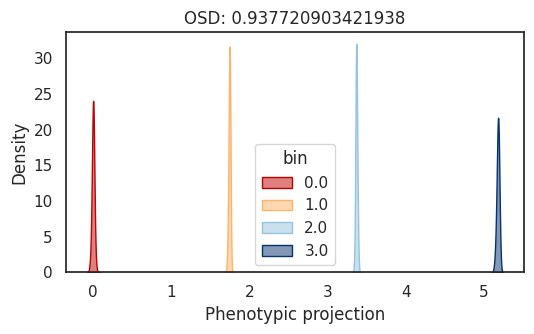

In [9]:
proj_points, osd, osd_val, sus, res = get_osd_from_latents_torch(torch.tensor(latent_space_comb.iloc[:, :latent_dim].values), latent_space_comb['Bin'].to_numpy(), torch.tensor(latent_space_comb['CFM']), mode = "together", state='eval')
proj_df = pd.DataFrame(proj_points, columns=['value', 'bin'])
# plot phenotypic projection
sns.set(style="white")
cmap1 = cm.get_cmap('gist_heat')
cmap2 = cm.get_cmap('Blues')
custom_palette = [cmap1(0.5), cmap1(0.85), cmap2(0.4), cmap2(0.99)]
bin_order = ['0', '1', '2', '3']
legend_labels = ['Strong susceptible', 'Weak susceptible', 'Weak resilient', 'Strong resilient']
plt.figure(figsize=(5.5, 3.5))
ax = sns.kdeplot(data=proj_df, x='value',hue="bin",palette=custom_palette,fill=True,alpha=0.5,
                 bw_adjust=3, common_norm=False)
if not ax.legend_:
    plt.legend(title="bin",labels=proj_df["bin"].unique(),bbox_to_anchor=(1.05, 1))
plt.title("")
plt.xlabel('Phenotypic projection')
plt.title(f'OSD: {osd}')
plt.tight_layout()
plt.show()

In [10]:
# finding the phenotypic projection the original way 
def project_row(row):
    coords = row[coord_cols].values
    proj, dist = line_coordinates_euclidean(sus, res, coords)
    return pd.Series({'Projected': proj,'Signed_Distance': dist})
coord_cols = latent_space_comb.iloc[:, :latent_dim].columns
sus = latent_space_comb.iloc[latent_space_comb['CFM'].nsmallest(1000).index, :latent_dim].apply(np.mean, axis=0).values
res = latent_space_comb.iloc[latent_space_comb['CFM'].nlargest(1000).index, :latent_dim].apply(np.mean, axis=0).values

projections = latent_space_comb.apply(project_row, axis=1)

df = pd.concat([
    latent_space_comb.reset_index(drop=True),
    pd.DataFrame(projections['Projected'].tolist(), columns=[f'Proj_{i+1}' for i in range(10)]),
    projections[['Signed_Distance']]], axis=1)
df.rename(columns={df.columns[-1]: 'PP'}, inplace=True)

/tmp/ipykernel_1485986/3593912585.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap1 = cm.get_cmap('gist_heat')
/tmp/ipykernel_1485986/3593912585.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap2 = cm.get_cmap('Blues')


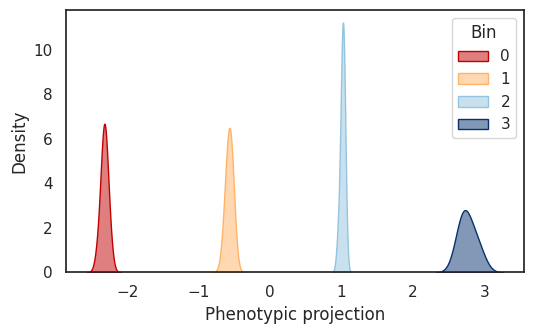

In [11]:
sns.set(style="white")
import matplotlib.cm as cm
cmap1 = cm.get_cmap('gist_heat')
cmap2 = cm.get_cmap('Blues')
custom_palette = [cmap1(0.5), cmap1(0.85), cmap2(0.4), cmap2(0.99)]
bin_order = ['0', '1', '2', '3']
plt.figure(figsize=(5.5, 3.5))
ax = sns.kdeplot(data=df,x='PP',hue="Bin",palette=custom_palette,fill=True,alpha=0.5,
                 bw_adjust=3, common_norm=False)
plt.title("")
plt.xlabel('Phenotypic projection')
plt.tight_layout()
plt.show()

/home/rachel/miniforge3/envs/mm-vae/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


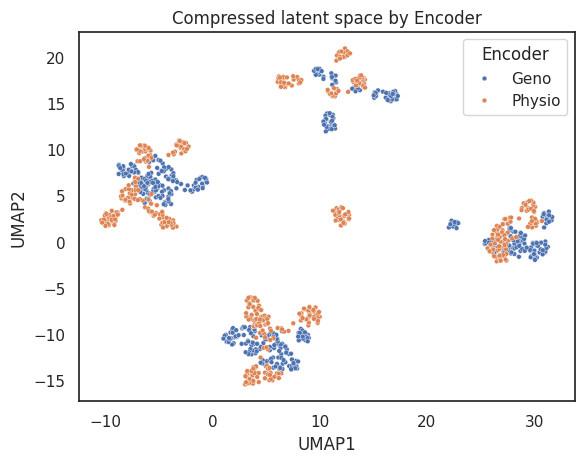

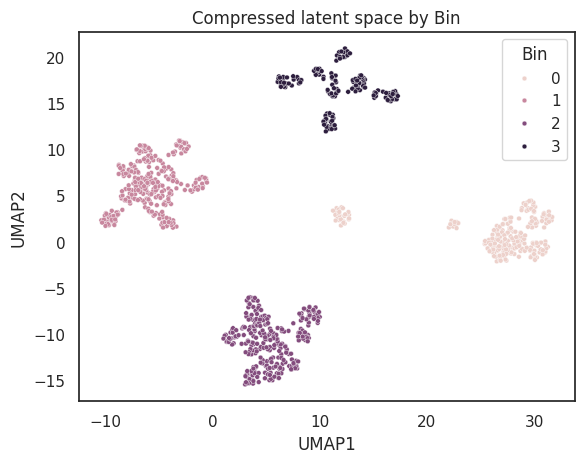

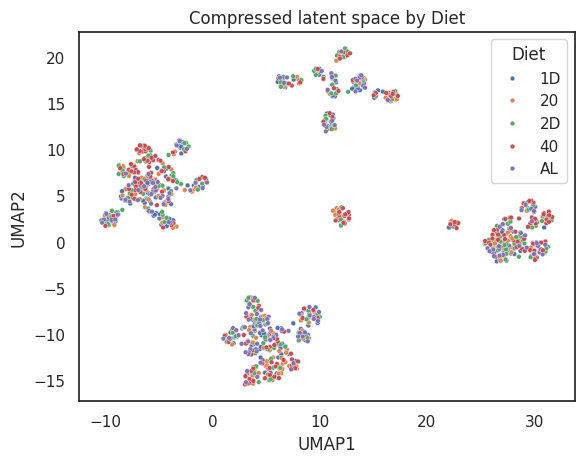

In [12]:
# make umap object 
reducer = umap.UMAP(n_neighbors=50, min_dist=1, n_components=2, random_state=random_seed)
embedding = reducer.fit_transform(latent_space_comb.iloc[:, :latent_dim])
# generate embedding dataframe from compressed representation
embedding_df = pd.DataFrame(embedding, columns=['UMAP1', 'UMAP2'])
embedding_df.to_csv(os.path.join(results_folder, 'latent_umap_embeddings.csv')) # save embedding 
for hue in hues: 
    embedding_df[hue] = latent_space_comb[hue]
# plot umap colored by each of the hues
for hue in hues: 
    plt.figure()
    if hue == 'bin':
        sns.scatterplot(x='UMAP1', y='UMAP2', hue=hue, data=embedding_df, s=12)
    else: 
        sns.scatterplot(x='UMAP1', y='UMAP2', hue=hue, data=embedding_df, s=12)
    plt.title(f'Compressed latent space by {hue}')

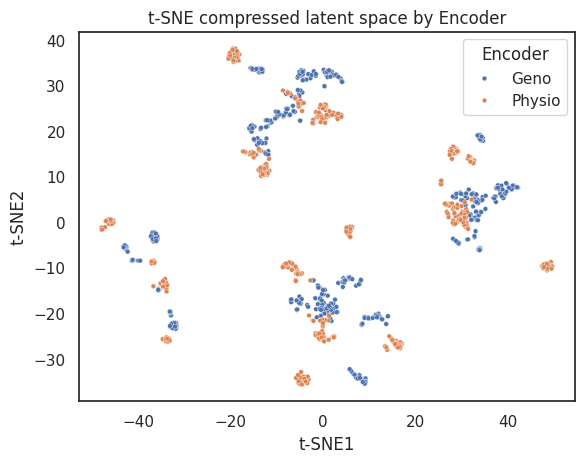

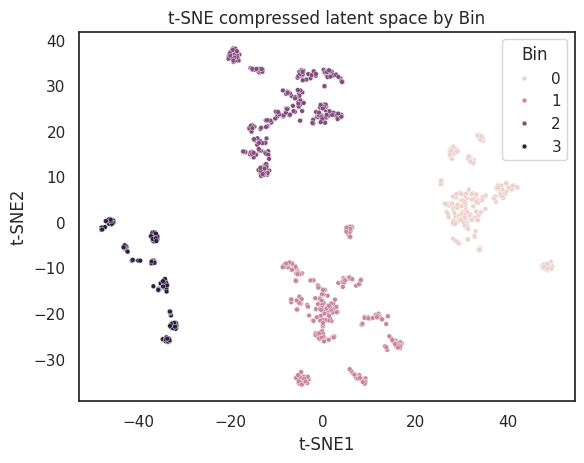

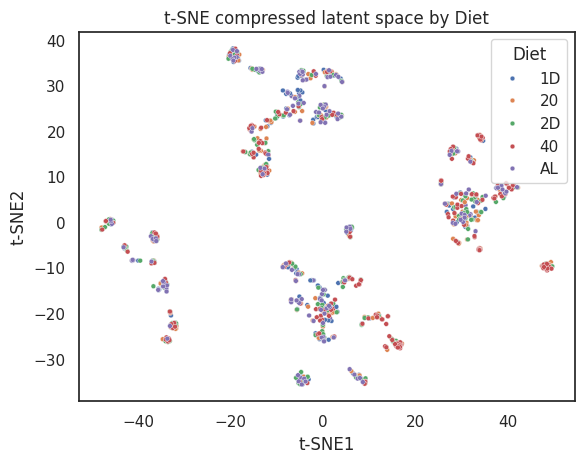

In [13]:
# do the same with tsne dim reduction
tsne = TSNE(n_components=2, perplexity=30, random_state=random_seed)
tsne_embeddings = tsne.fit_transform(latent_space_comb.iloc[:, :latent_dim])
tsne_embedding_df = pd.DataFrame(tsne_embeddings, columns=['t-SNE1', 't-SNE2'])
for hue in hues: 
    tsne_embedding_df[hue] = latent_space_comb[hue]
    plt.figure()
    if hue == 'bin':
        sns.scatterplot(x='t-SNE1', y='t-SNE2', hue=hue, data=tsne_embedding_df, s=12)
    else:
        sns.scatterplot(x='t-SNE1', y='t-SNE2', hue=hue, data=tsne_embedding_df, s=12)
    plt.title(f't-SNE compressed latent space by {hue}')

Plot resulting phenotypic projection

/tmp/ipykernel_1485986/2244209447.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap1 = cm.get_cmap('gist_heat')
/tmp/ipykernel_1485986/2244209447.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap2 = cm.get_cmap('Blues')


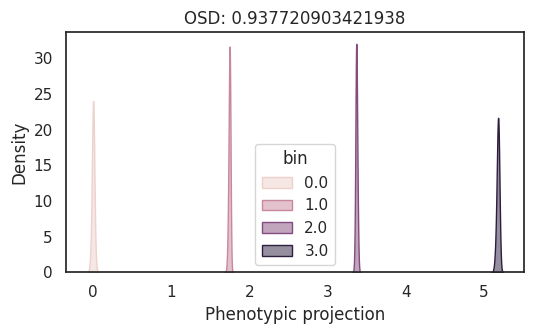

In [14]:
# reconfigure shape of latents
proj_points, osd, osd_val, sus, res = get_osd_from_latents_torch(torch.tensor(latent_space_comb.iloc[:, :latent_dim].values), latent_space_comb['Bin'].to_numpy(), torch.tensor(latent_space_comb['CFM']), mode = "together", state='eval')
proj_df = pd.DataFrame(proj_points, columns=['value', 'bin'])
# plot phenotypic projection
sns.set(style="white")
cmap1 = cm.get_cmap('gist_heat')
cmap2 = cm.get_cmap('Blues')
bin_order = ['0', '1', '2', '3']
legend_labels = ['Strong susceptible', 'Weak susceptible', 'Weak resilient', 'Strong resilient']
plt.figure(figsize=(5.5, 3.5))
ax = sns.kdeplot(data=proj_df, x='value',hue="bin",fill=True,alpha=0.5,
                 bw_adjust=3, common_norm=False)
if not ax.legend_:
    plt.legend(title="bin",labels=proj_df["bin"].unique(),bbox_to_anchor=(1.05, 1))
plt.title("")
plt.xlabel('Phenotypic projection')
plt.title(f'OSD: {osd}')
plt.tight_layout()
plt.show()

Calculate correlations between latent variables

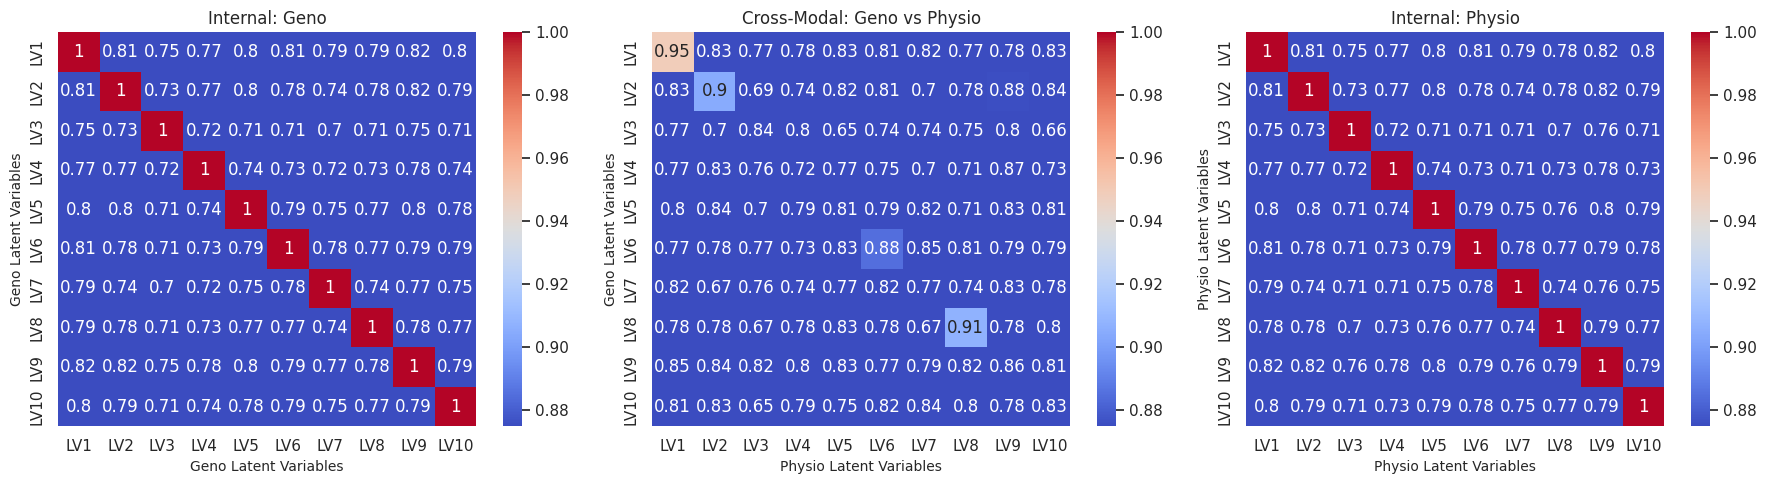

In [15]:
from itertools import combinations_with_replacement
unique_encoders = latent_space_comb['Encoder'].unique()
encoder_pairs = list(combinations_with_replacement(unique_encoders, 2))
latent_cols = latent_space_comb.iloc[:, :latent_dim].columns 

# Filter pairs first to ensure we only plot valid combinations
valid_pairs = []
for enc1, enc2 in encoder_pairs:
    z1 = latent_space_comb[latent_space_comb['Encoder'] == enc1].iloc[:, :latent_dim]
    z2 = latent_space_comb[latent_space_comb['Encoder'] == enc2].iloc[:, :latent_dim]
    if len(z1) == len(z2):
        valid_pairs.append((enc1, enc2, z1, z2))
    else:
        
        print(f"Skipping {enc1} vs {enc2} due to row count mismatch.")

num_plots = len(valid_pairs)

if num_plots > 0:
    # Initialize a single figure with subplots side-by-side
    fig, axes = plt.subplots(1, num_plots, figsize=(6 * num_plots, 5), sharey=False)
    
    # Ensure axes is iterable even if there's only 1 plot
    if num_plots == 1:
        axes = [axes]

    for i, (enc1, enc2, z1, z2) in enumerate(valid_pairs):
        ax = axes[i]
        
        # Calculate cross-correlation
        stacked = np.hstack((z1, z2))
        full_corr = np.corrcoef(stacked.T)
        cross_corr = full_corr[:latent_dim, latent_dim:]

        # Plot heatmap on the specific subplot axis
        # cbar_ax creates a shared or individual colorbar; keeping it standard here
        sns.heatmap(
            cross_corr, 
            annot=True, 
            cmap='coolwarm', 
            xticklabels=latent_cols,
            yticklabels=latent_cols, 
            vmin=0.875, 
            vmax=1,
            ax=ax  # Directs seaborn to the correct subplot
        )
        
        ax.set_xlabel(f"{enc2} Latent Variables", fontsize=10)
        ax.set_ylabel(f"{enc1} Latent Variables", fontsize=10)
        
        if enc1 == enc2:
            ax.set_title(f"Internal: {enc1}", fontsize=12)
        else:
            ax.set_title(f"Cross-Modal: {enc1} vs {enc2}", fontsize=12)

    plt.tight_layout()
    
    # Save the combined figure
    save_path = os.path.join(results_folder, "Combined_Latent_Correlations.png")
    plt.savefig(save_path, dpi=300)
    plt.show()
else:
    print("No valid encoder pairs found to plot.")

Plot distance between paired datapoints

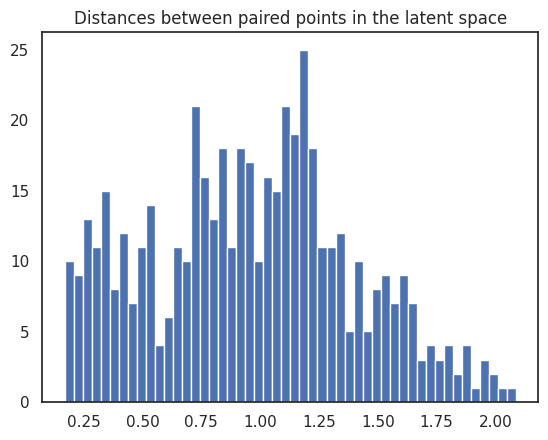

In [16]:
latent_space_comb['pair'] = np.tile(np.arange(1, int(len(latent_space_comb) / 2) + 1), 2)
geno = latent_space_geno.iloc[:, :latent_dim]
physio = latent_space_physio.iloc[:, :latent_dim]
paired_distances = np.linalg.norm(geno.values - physio.values, axis=1)
plt.hist(paired_distances, bins=50)
plt.title('Distances between paired points in the latent space')
plt.savefig(os.path.join(results_folder, 'paired_distances.png'))

Latent traversal across dimensions

In [17]:
# initialize 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
m1_var_path = '/home/rachel/Desktop/mm-vae data/caloric_restriction_DO_mice/genoprobs_var.csv' 
m2_var_path = '/home/rachel/Desktop/mm-vae data/caloric_restriction_DO_mice/physio_var.csv' 
m1_var = pd.read_csv(m1_var_path)
m2_var = pd.read_csv(m2_var_path)
vae = torch.load(os.path.join(results_folder, f'saved_model_epoch{epoch}.pth'), map_location=device, weights_only=False)
model_type='CGMVAE'

/home/rachel/miniforge3/envs/mm-vae/lib/python3.12/site-packages/torch/cuda/__init__.py:182: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [18]:
#initialize relevant functions
# function that takes a latent point, finds the count of the k nearest points, and returns the most popular label 
def find_label(all_latent_data, traversal_point, y, k=20):
    device = traversal_point.device
    all_latent_data = all_latent_data.to(device)
    y = y.to(device)
    dist = torch.linalg.norm(all_latent_data - traversal_point.squeeze(0), dim=1)
    _, top_k_indices = torch.topk(dist, k, largest=False)
    label = torch.mode(y[top_k_indices]).values.item()
    return torch.tensor(label, dtype=torch.long)

In [19]:
from scipy.stats import pearsonr

def latent_traversal_summary(
    model,
    latent_data,
    device,
    traversal_dim,
    latent_dims,
    model_type,
    y,
    num_steps=100,
    k=20,
):
    model.train()

    mean_latent_data = torch.tensor(
        latent_data.iloc[:, :latent_dims].mean(axis=0).values.reshape(1, latent_dims),
        dtype=torch.float32,
    )

    traversal_values = torch.linspace(
        latent_data.iloc[:, traversal_dim - 1].min(),
        latent_data.iloc[:, traversal_dim - 1].max(),
        steps=num_steps,
    )

    with torch.no_grad():
        z_batch = mean_latent_data.repeat(num_steps, 1).to(device)
        z_batch[:, traversal_dim - 1] = traversal_values.to(device)

        if model_type == "VAE":
            recon_m1, _ = model.vaes[0].decode(z_batch)
            recon_m2, _ = model.vaes[1].decode(z_batch)
        else:
            latent_ref = torch.tensor(
                latent_data.iloc[:, :latent_dims].values,
                dtype=torch.float32,
                device=device,
            )
            labels = torch.stack([
                find_label(latent_ref, z.unsqueeze(0), y, k) for z in z_batch
            ]).to(device)

            recon_m1, _ = model.vaes[0].decode(z_batch, labels)
            recon_m2, _ = model.vaes[1].decode(z_batch, labels)

    recon_m1 = recon_m1.detach().cpu().numpy()
    recon_m2 = recon_m2.detach().cpu().numpy()
    traversal_values_np = traversal_values.cpu().numpy()

    cfm1 = recon_m1[:, -1]
    cfm2 = recon_m2[:, -1]

    corr1, _ = pearsonr(traversal_values_np, cfm1)
    corr2, _ = pearsonr(traversal_values_np, cfm2)

    return {
        "traversal_values": traversal_values_np,
        "traversal_range": latent_data.iloc[:, traversal_dim - 1].max() - latent_data.iloc[:, traversal_dim - 1].min(),
        "geno_recon": recon_m1,
        "physio_recon": recon_m2,
        "geno_feature_var": np.var(recon_m1, axis=0),
        "physio_feature_var": np.var(recon_m2, axis=0),
        "geno_feature_mean_abs_change": np.mean(np.abs(recon_m1 - recon_m1[0]), axis=0),
        "physio_feature_mean_abs_change": np.mean(np.abs(recon_m2 - recon_m2[0]), axis=0),
        "geno_total_mean_feature_var": float(np.mean(np.var(recon_m1, axis=0))),
        "physio_total_mean_feature_var": float(np.mean(np.var(recon_m2, axis=0))),
        "geno_total_median_feature_var": float(np.median(np.var(recon_m1, axis=0))),
        "physio_total_median_feature_var": float(np.median(np.var(recon_m2, axis=0))),
        "geno_cfm_corr": float(corr1),
        "physio_cfm_corr": float(corr2),
    }

In [20]:
all_dims = list(range(1, latent_dim + 1))
y = torch.tensor(latent_space_comb["Bin"].values).int()

feature_var_rows = []
cfm_var_rows = []
cfm_rows = []
geno_scores = []
physio_scores = []
geno_cfm_corr = []
physio_cfm_corr = []
geno_recon_rows = []
physio_recon_rows = []

# Collect per-traversal statistics inside the loop; build summary tables afterward.
for dim in all_dims:
    out = latent_traversal_summary(
        model=vae,
        latent_data=latent_space_comb,
        device=device,
        traversal_dim=dim,
        latent_dims=latent_dim,
        model_type=model_type,
        y=y,
        num_steps=20,
        k=20,
    )

    geno_recon = out["geno_recon"]
    physio_recon = out["physio_recon"]

    geno_step_df = pd.DataFrame(geno_recon)
    geno_step_df.insert(0, "step", np.arange(len(geno_step_df)))
    geno_step_df.insert(0, "latent_dim", dim)
    geno_recon_df = geno_step_df.melt(
        id_vars=["latent_dim", "step"],
        var_name="feature_idx",
        value_name="reconstruction",
    )
    geno_recon_rows.append(geno_recon_df)

    physio_step_df = pd.DataFrame(physio_recon)
    physio_step_df.insert(0, "step", np.arange(len(physio_step_df)))
    physio_step_df.insert(0, "latent_dim", dim)
    physio_recon_df = physio_step_df.melt(
        id_vars=["latent_dim", "step"],
        var_name="feature_idx",
        value_name="reconstruction",
    )
    physio_recon_rows.append(physio_recon_df)

    geno_feature_var = np.var(geno_recon, axis=0)
    physio_feature_var = np.var(physio_recon, axis=0)

    for feature_idx, var_val in enumerate(geno_feature_var, start=1):
        feature_var_rows.append({
            "latent_dim": dim,
            "modality": "Geno",
            "feature_idx": feature_idx,
            "variance": var_val,
        })

    for feature_idx, var_val in enumerate(physio_feature_var, start=1):
        feature_var_rows.append({
            "latent_dim": dim,
            "modality": "Physio",
            "feature_idx": feature_idx,
            "variance": var_val,
        })

    cfm_var_rows.append({
        "latent_dim": dim,
        "modality": "Geno",
        "cfm_variance": float(np.var(geno_recon[:, -1])),
    })
    cfm_var_rows.append({
        "latent_dim": dim,
        "modality": "Physio",
        "cfm_variance": float(np.var(physio_recon[:, -1])),
    })

    geno_scores.append(out["geno_total_mean_feature_var"])
    physio_scores.append(out["physio_total_mean_feature_var"])
    geno_cfm_corr.append(out["geno_cfm_corr"])
    physio_cfm_corr.append(out["physio_cfm_corr"])

    for val in geno_recon[:, -1]:
        cfm_rows.append({
            "latent_dim": dim,
            "modality": "Geno",
            "cfm_value": val,
        })

    for val in physio_recon[:, -1]:
        cfm_rows.append({
            "latent_dim": dim,
            "modality": "Physio",
            "cfm_value": val,
        })

geno_recon_df = pd.concat(geno_recon_rows, ignore_index=True)
physio_recon_df = pd.concat(physio_recon_rows, ignore_index=True)

cfm_df = pd.DataFrame(cfm_rows)

feature_var_df = pd.DataFrame(feature_var_rows)
cfm_var_df = pd.DataFrame(cfm_var_rows)

feature_summary_df = (
    feature_var_df
    .groupby(["latent_dim", "modality"], as_index=False)
    .agg(
        mean_variance=("variance", "mean"),
        median_variance=("variance", "median"),
        std_variance=("variance", "std"),
        n_features=("variance", "size"),
    )
)


cfm_summary_df = cfm_var_df.copy()

feature_summary_df
geno_recon_df
physio_recon_df

,latent_dim,step,feature_idx,reconstruction
0,1,0,0,-1.251506
1,1,1,0,-1.263375
2,1,2,0,-1.274596
3,1,3,0,-1.281599
4,1,4,0,-1.282534
...,...,...,...,...
6995,10,15,34,-0.816384
6996,10,16,34,-0.720659
6997,10,17,34,-0.543602
6998,10,18,34,-0.274919


In [21]:
traversal_ranges = out["traversal_range"]
std5 = 5 * 0.08
traversal_ranges, std5

(2.7040336000000003, 0.4)

In [22]:
traversal_values = out["traversal_values"]
len(traversal_values)

20

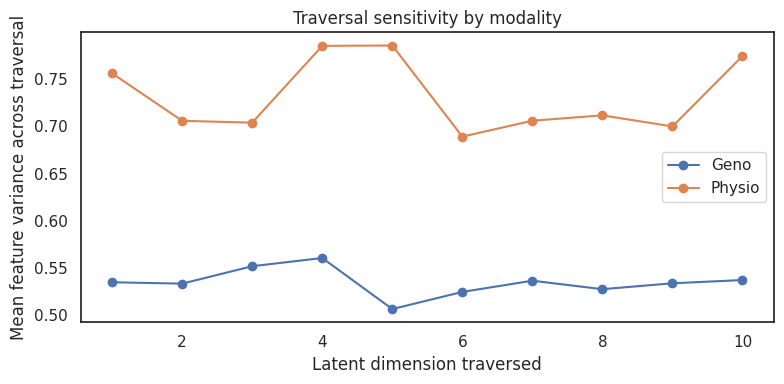

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(all_dims, geno_scores, marker="o", label="Geno")
plt.plot(all_dims, physio_scores, marker="o", label="Physio")
plt.xlabel("Latent dimension traversed")
plt.ylabel("Mean feature variance across traversal")
plt.title("Traversal sensitivity by modality")
plt.legend()
plt.tight_layout()
plt.show()

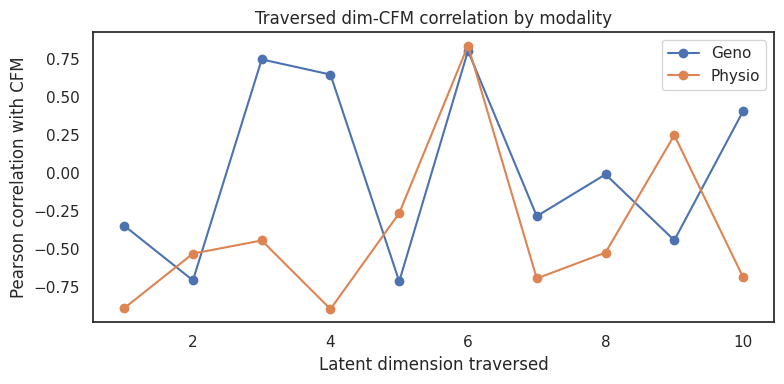

In [24]:
plt.figure(figsize=(8, 4))
plt.plot(all_dims, geno_cfm_corr, marker="o", label="Geno")
plt.plot(all_dims, physio_cfm_corr, marker="o", label="Physio")
plt.xlabel("Latent dimension traversed")
plt.ylabel("Pearson correlation with CFM")
plt.title("Traversed dim-CFM correlation by modality")
plt.legend()
plt.tight_layout()
plt.show()

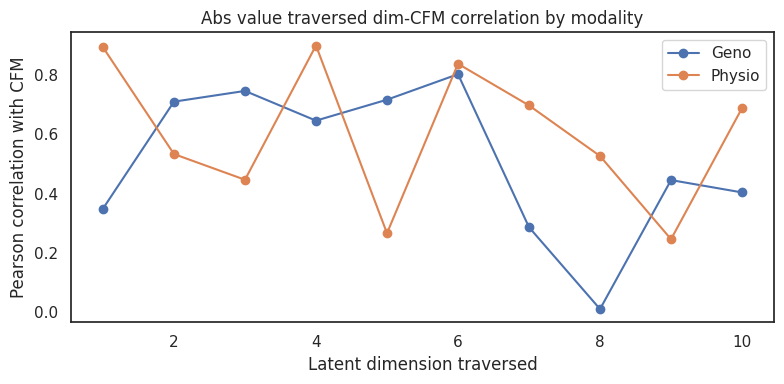

In [25]:
plt.figure(figsize=(8, 4))
plt.plot(all_dims, np.abs(geno_cfm_corr), marker="o", label="Geno")
plt.plot(all_dims, np.abs(physio_cfm_corr), marker="o", label="Physio")
plt.xlabel("Latent dimension traversed")
plt.ylabel("Pearson correlation with CFM")
plt.title("Abs value traversed dim-CFM correlation by modality")
plt.legend()
plt.tight_layout()
plt.show()

Plot normal latent correlations with CFM to see if they follow similar patterns

In [26]:
original_geno_corr = []
original_physio_corr = []
physio_corr = []
for dim in range(latent_dim):
    geno_corr, _ = pearsonr(latent_space_geno.iloc[:, dim], latent_space_geno['CFM'])
    physio_corr, _ = pearsonr(latent_space_physio.iloc[:, dim], latent_space_physio['CFM'])
    original_geno_corr.append(geno_corr)
    original_physio_corr.append(physio_corr)

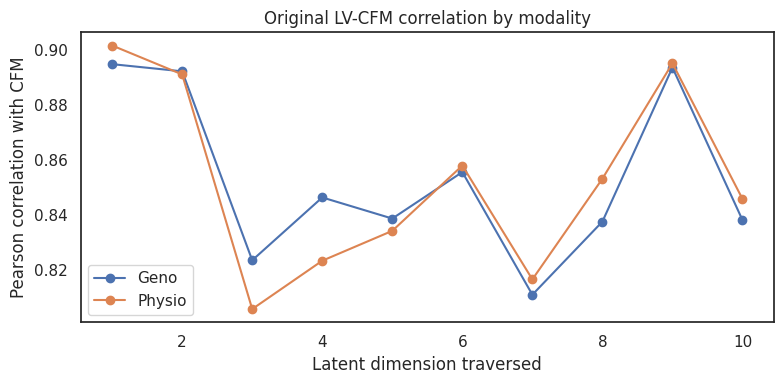

In [27]:
plt.figure(figsize=(8, 4))
plt.plot(all_dims, np.abs(original_geno_corr), marker="o", label="Geno")
plt.plot(all_dims, np.abs(original_physio_corr), marker="o", label="Physio")
plt.xlabel("Latent dimension traversed")
plt.ylabel("Pearson correlation with CFM")
plt.title("Original LV-CFM correlation by modality")
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
all_dims = list(range(1, latent_dim + 1))
y = torch.tensor(latent_space_comb["Bin"].values).int()

feature_var_rows = []
cfm_var_rows = []
cfm_rows = []

for dim in all_dims:
    out = latent_traversal_summary(
        model=vae,
        latent_data=latent_space_comb,
        device=device,
        traversal_dim=dim,
        latent_dims=latent_dim,
        model_type=model_type,
        y=y,
        num_steps=10,
        k=20,
    )

    geno_recon = out["geno_recon"]
    physio_recon = out["physio_recon"]

    geno_feature_var = np.var(geno_recon, axis=0)
    physio_feature_var = np.var(physio_recon, axis=0)

    for feature_idx, var_val in enumerate(geno_feature_var, start=1):
        feature_var_rows.append({
            "latent_dim": dim,
            "modality": "Geno",
            "feature_idx": feature_idx,
            "variance": var_val,
        })

    for feature_idx, var_val in enumerate(physio_feature_var, start=1):
        feature_var_rows.append({
            "latent_dim": dim,
            "modality": "Physio",
            "feature_idx": feature_idx,
            "variance": var_val,
        })

    cfm_var_rows.append({
        "latent_dim": dim,
        "modality": "Geno",
        "cfm_variance": float(np.var(geno_recon[:, -1])),
    })
    cfm_var_rows.append({
        "latent_dim": dim,
        "modality": "Physio",
        "cfm_variance": float(np.var(physio_recon[:, -1])),
    })


    for val in geno_recon[:, -1]:
        cfm_rows.append({
            "latent_dim": dim,
            "modality": "Geno",
            "cfm_value": val,
        })

    for val in physio_recon[:, -1]:
        cfm_rows.append({
            "latent_dim": dim,
            "modality": "Physio",
            "cfm_value": val,
        })

cfm_df = pd.DataFrame(cfm_rows)
cfm_df

feature_var_df = pd.DataFrame(feature_var_rows)
cfm_var_df = pd.DataFrame(cfm_var_rows)

feature_summary_df = (
    feature_var_df
    .groupby(["latent_dim", "modality"], as_index=False)
    .agg(
        mean_variance=("variance", "mean"),
        median_variance=("variance", "median"),
        std_variance=("variance", "std"),
        n_features=("variance", "size"),
    )
)

cfm_summary_df = cfm_var_df.copy()

feature_summary_df

,latent_dim,modality,mean_variance,median_variance,std_variance,n_features
0,1,Geno,0.530147,0.461688,0.286495,5875
1,1,Physio,0.742640,0.535756,0.960253,35
2,2,Geno,0.528829,0.460731,0.285247,5875
3,2,Physio,0.728224,0.535684,0.905128,35
4,3,Geno,0.552823,0.474075,0.310817,5875
5,3,Physio,0.715361,0.535684,0.857338,35
6,4,Geno,0.555882,0.475378,0.313842,5875
7,4,Physio,0.778713,0.535845,1.034676,35
8,5,Geno,0.504837,0.444989,0.263140,5875
9,5,Physio,0.773358,0.387123,1.108598,35


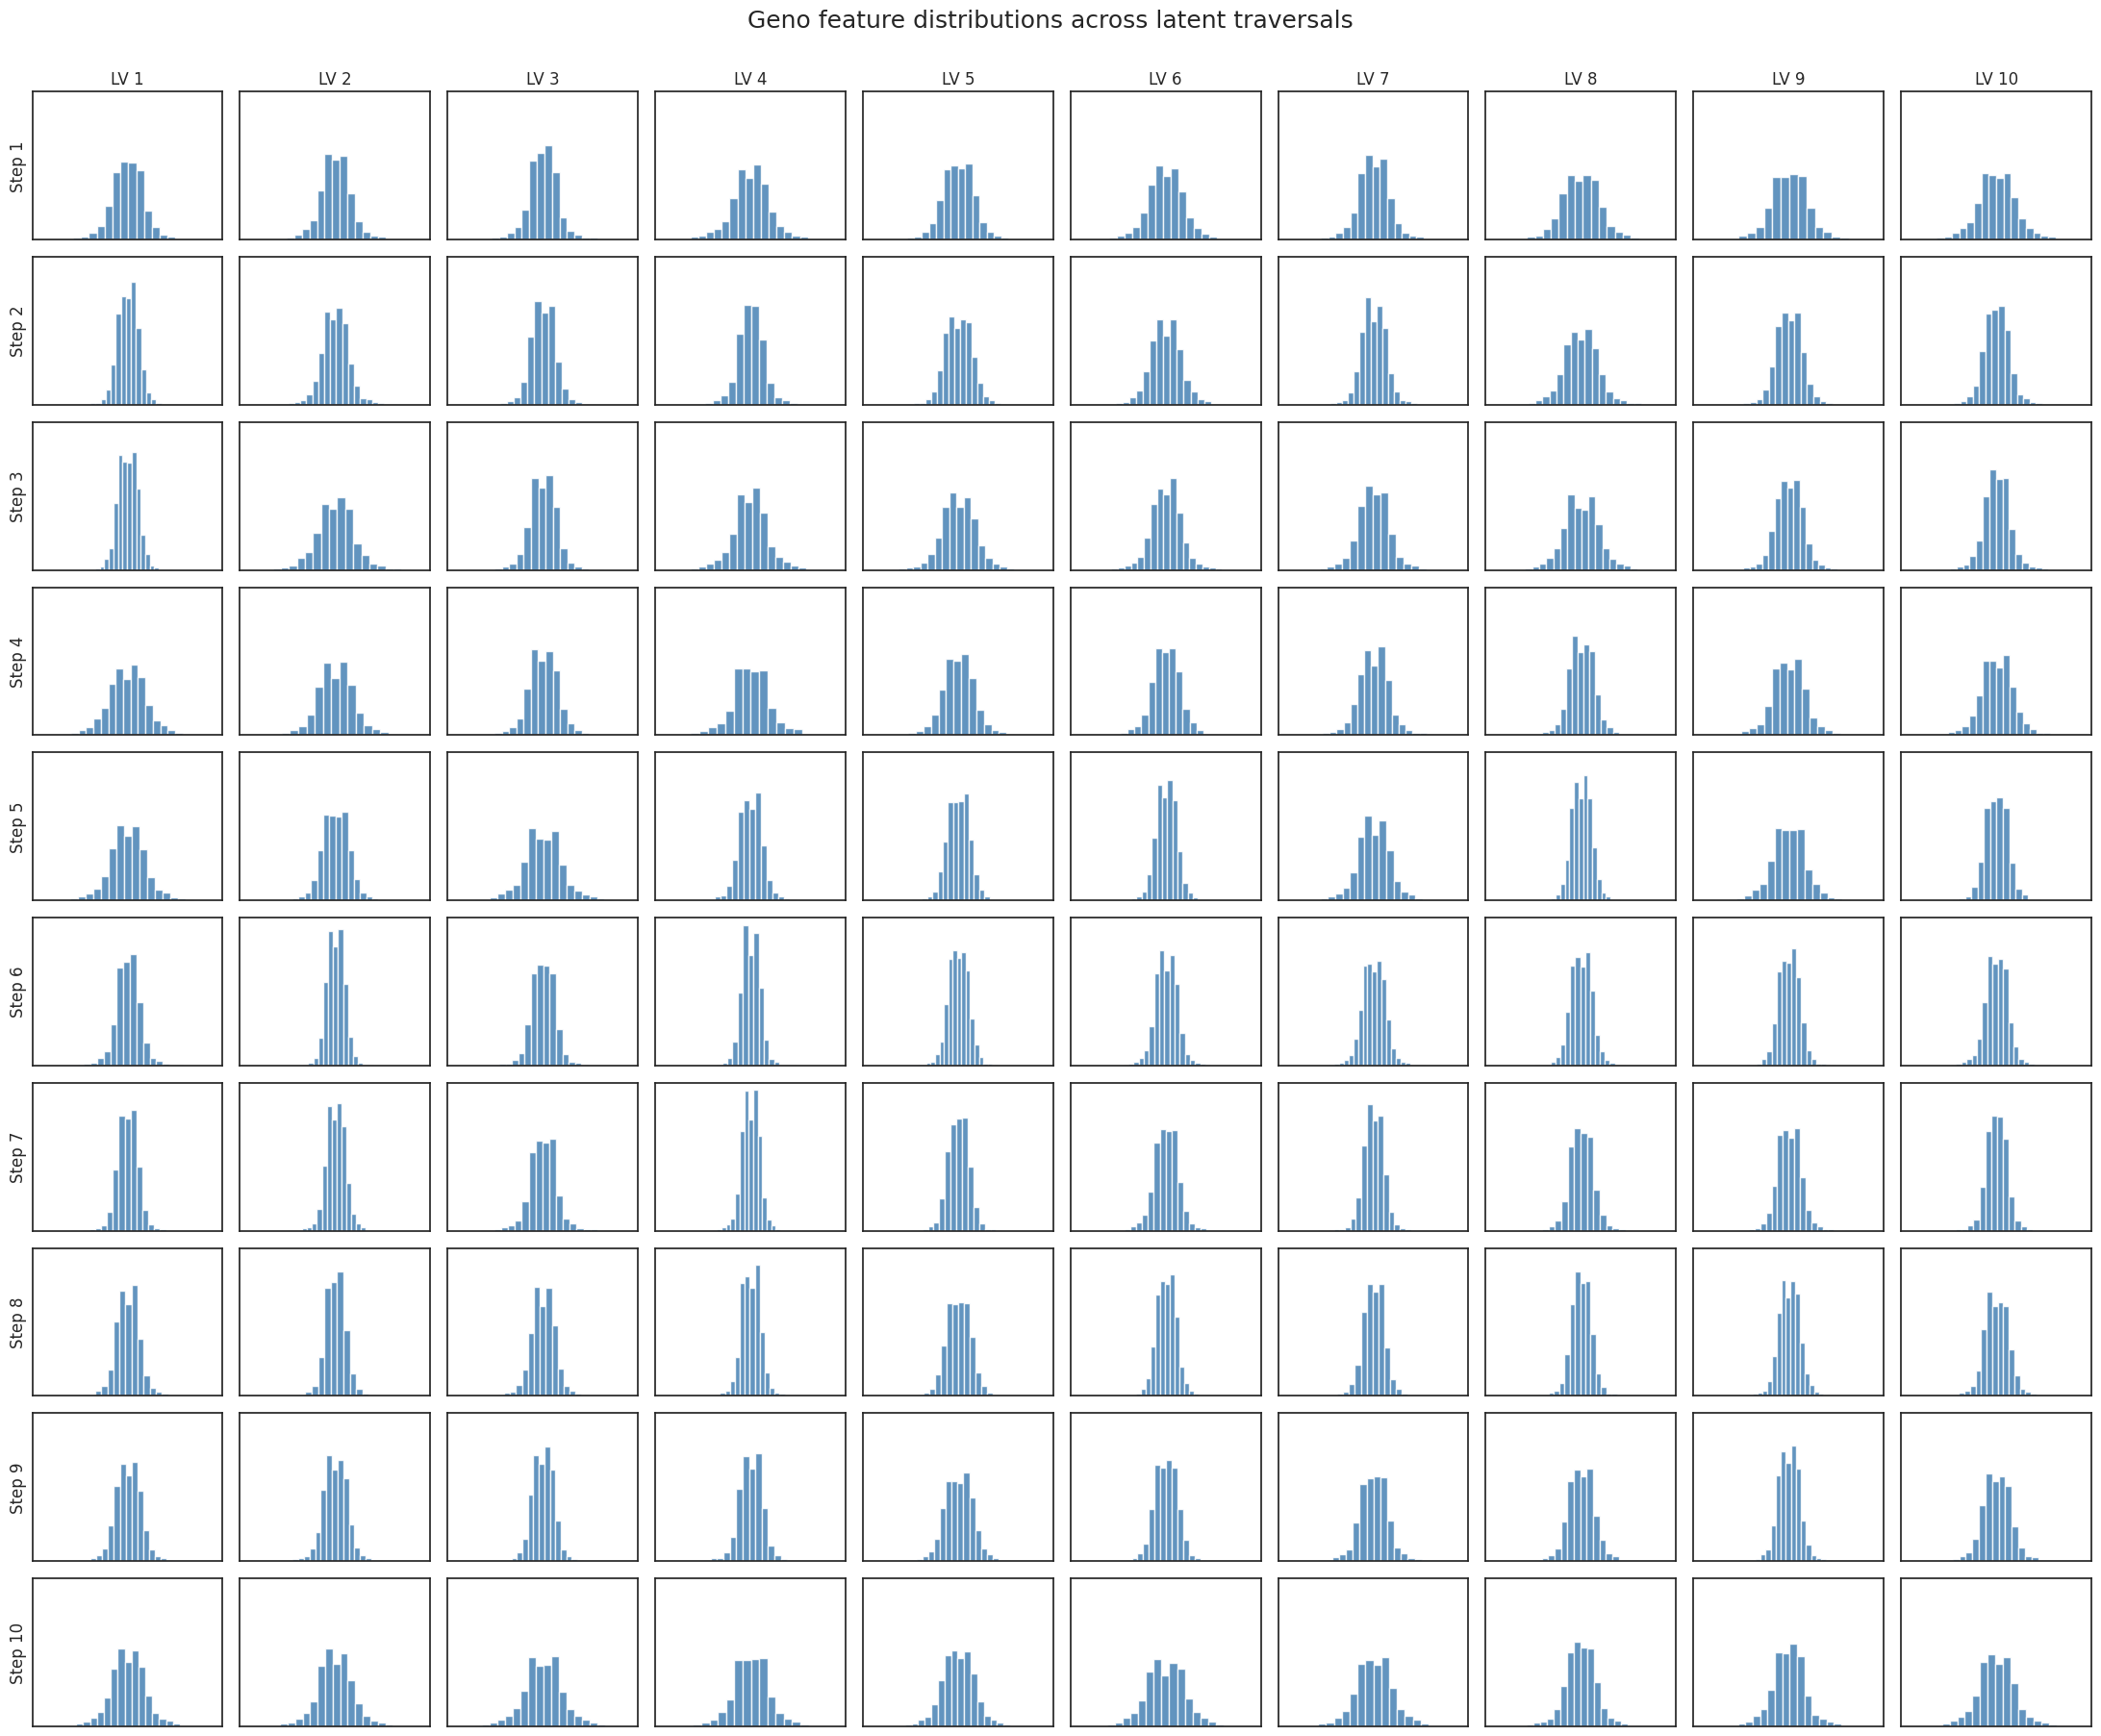

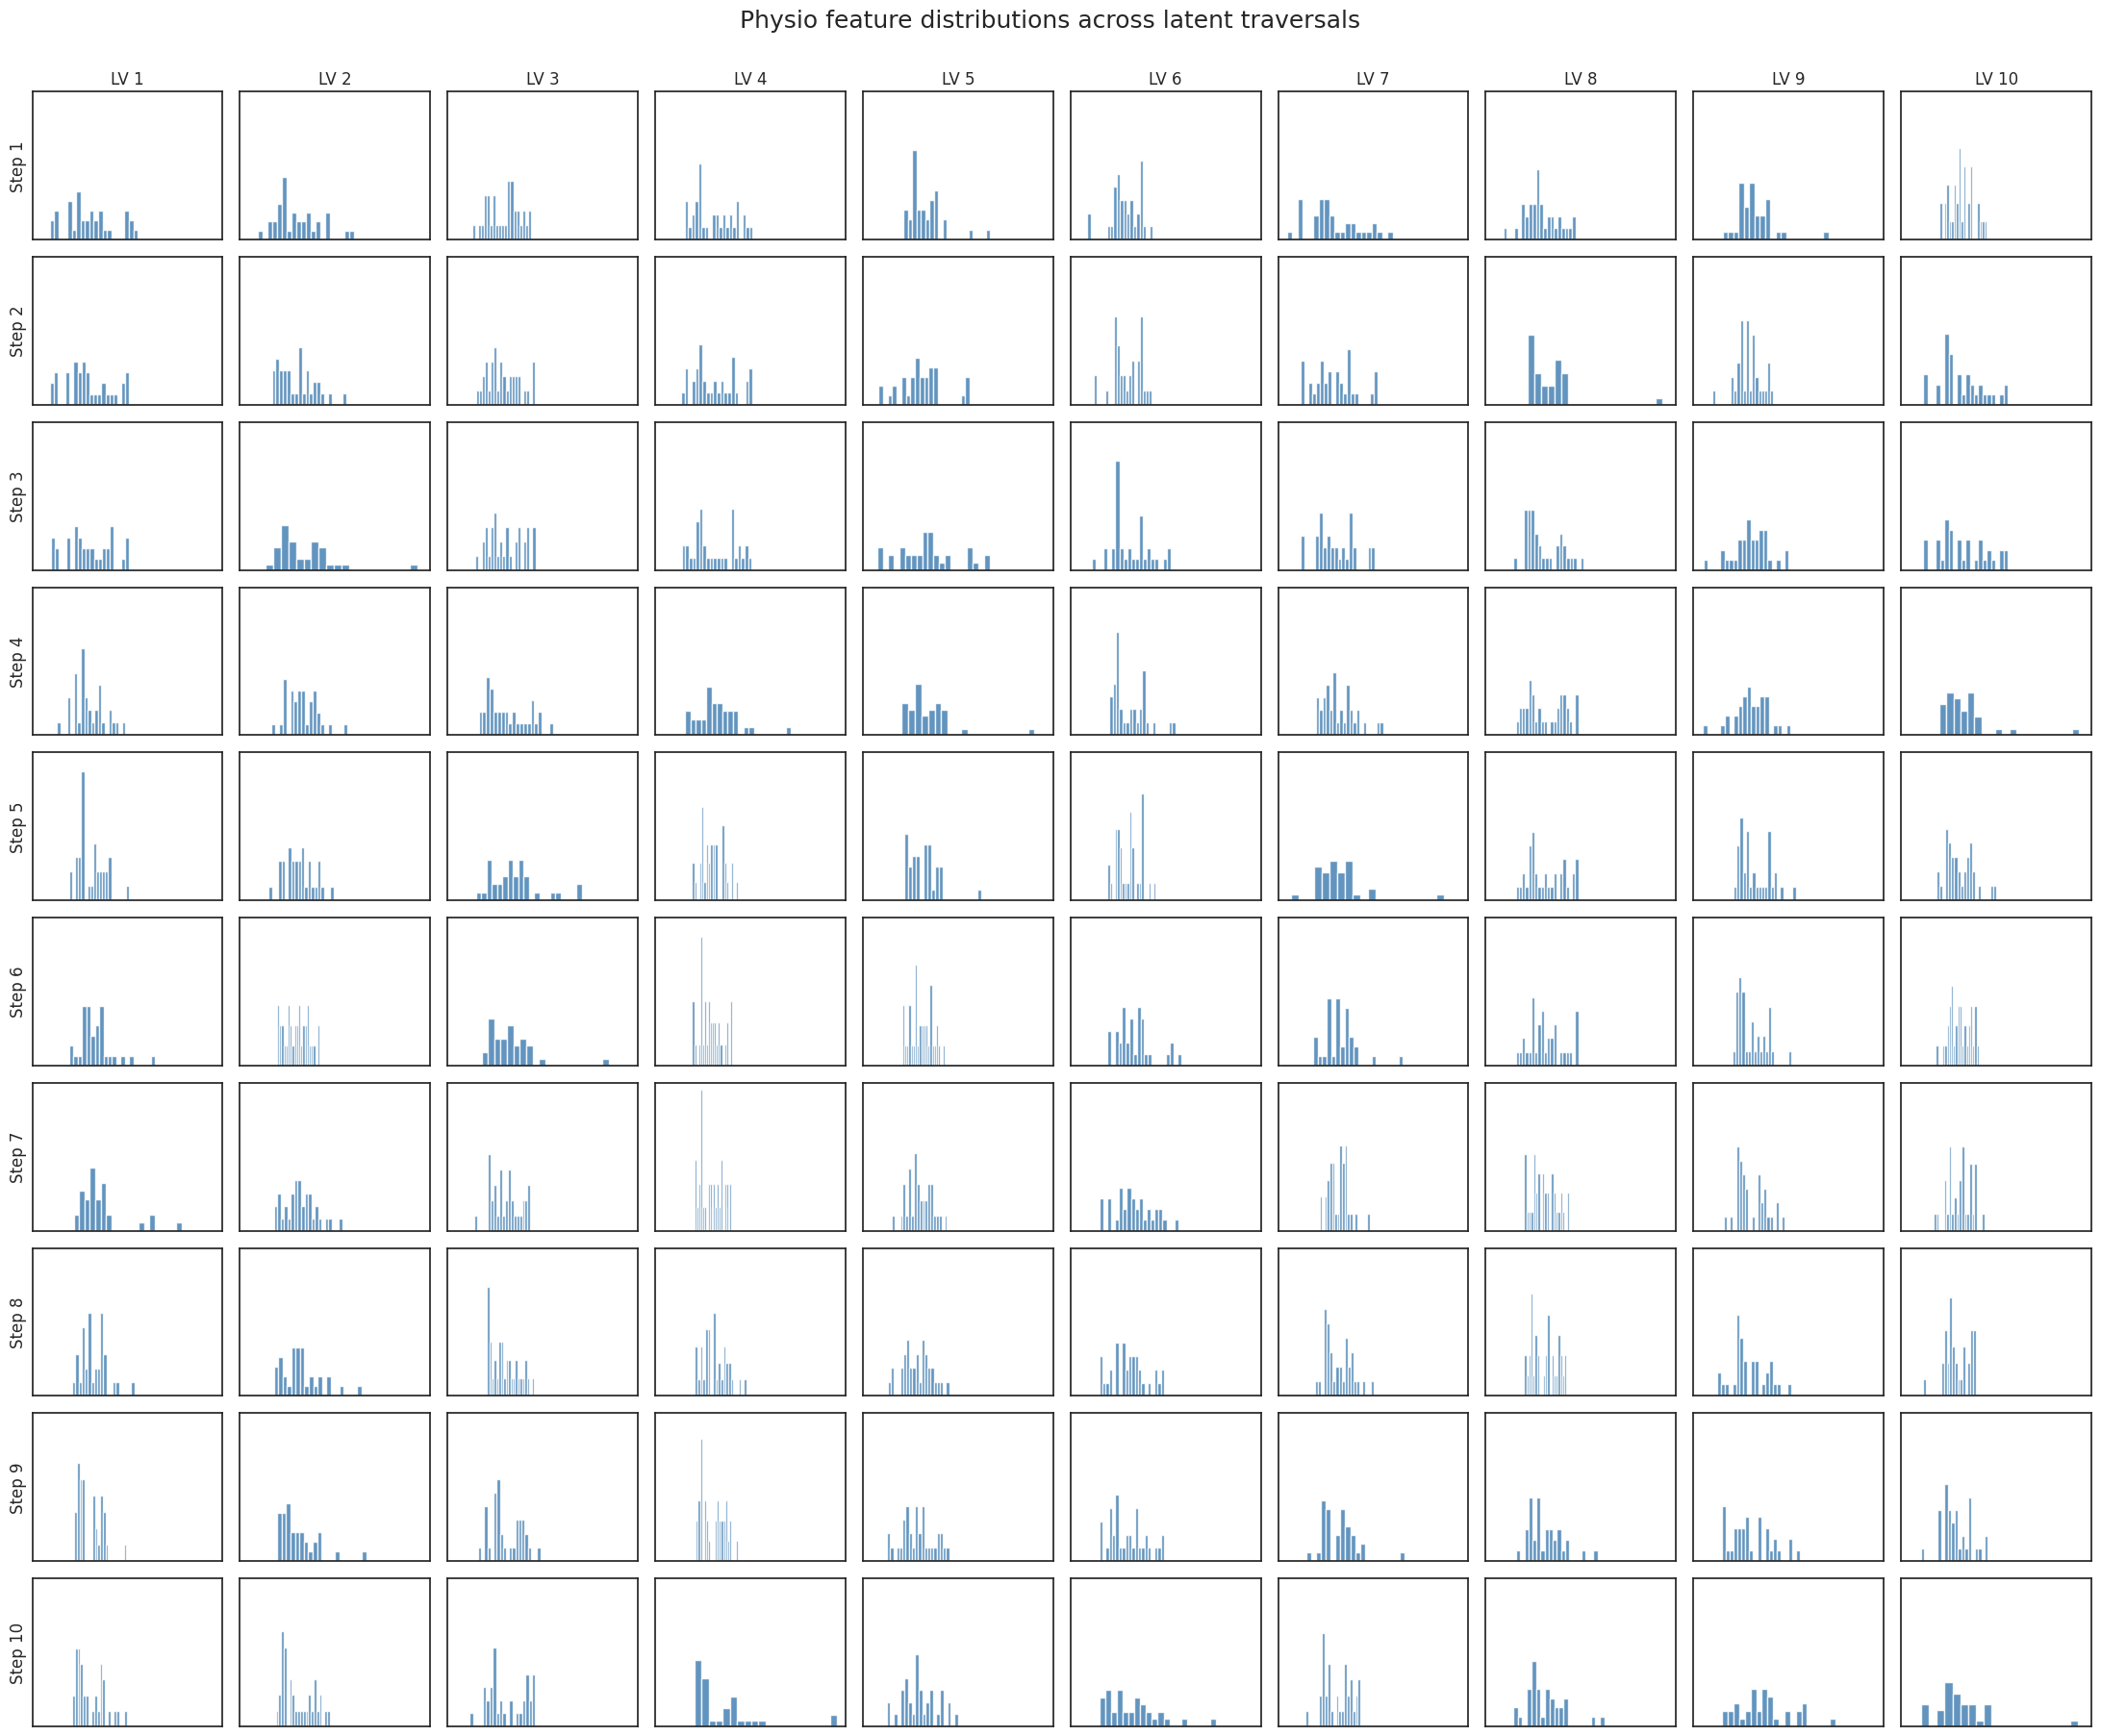

In [37]:
num_steps = 10

def plot_traversal_histogram_grid(modality_key, title, bins=20):
    fig, axes = plt.subplots(
        num_steps,
        latent_dim,
        figsize=(2.2 * latent_dim, 1.8 * num_steps),
        sharex=True,
        sharey=True,
    )
    axes = np.atleast_2d(axes)

    for dim in range(1, latent_dim + 1):
        out = latent_traversal_summary(
            model=vae,
            latent_data=latent_space_comb,
            device=device,
            traversal_dim=dim,
            latent_dims=latent_dim,
            model_type=model_type,
            y=y,
            num_steps=num_steps,
            k=20,
        )

        recon = np.asarray(out[modality_key])
        if recon.ndim > 2:
            recon = recon.reshape(recon.shape[0], -1)

        for step_idx in range(num_steps):
            ax = axes[step_idx, dim - 1]
            feature_values = np.asarray(recon[step_idx]).ravel()
            ax.hist(feature_values, bins=bins, color="steelblue", alpha=0.85, density=True)
            ax.set_xticks([])
            ax.set_yticks([])

            if step_idx == 0:
                ax.set_title(f"LV {dim}")
            if dim == 1:
                ax.set_ylabel(f"Step {step_idx + 1}")

    fig.suptitle(title, fontsize=18, y=1.002)
    fig.tight_layout()
    plt.show()

plot_traversal_histogram_grid("geno_recon", "Geno feature distributions across latent traversals")
plot_traversal_histogram_grid("physio_recon", "Physio feature distributions across latent traversals")

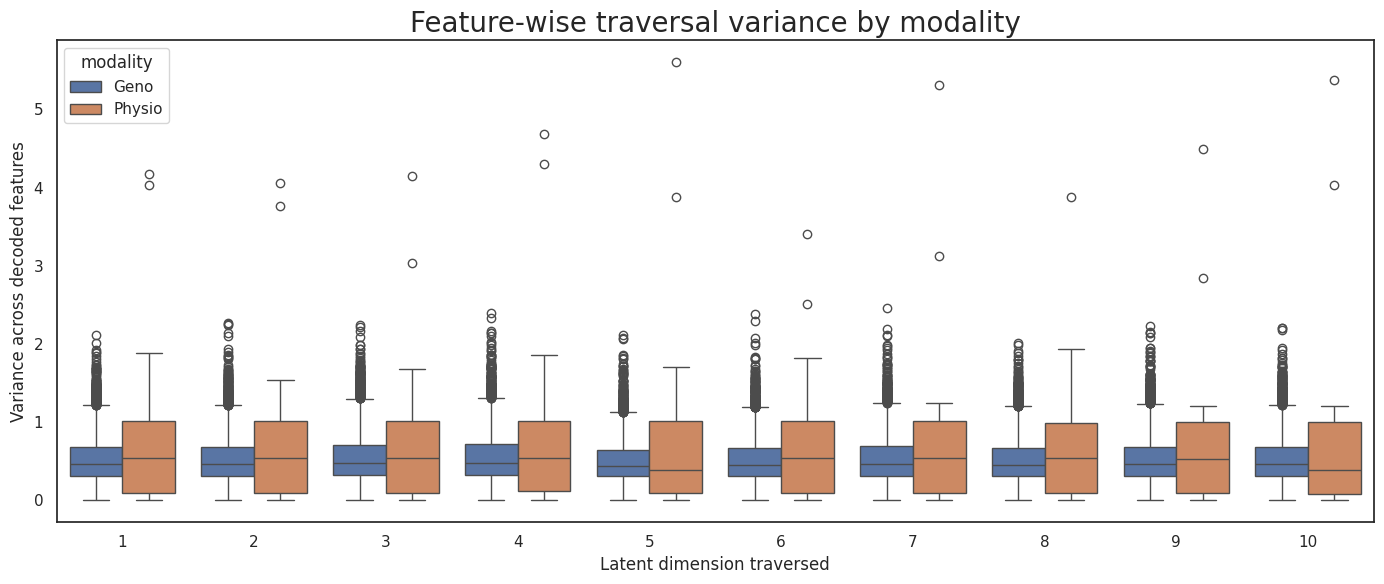

In [30]:
plt.figure(figsize=(14, 6))
sns.boxplot(
    data=feature_var_df,
    x="latent_dim",
    y="variance",
    hue="modality",
)
plt.xlabel("Latent dimension traversed")
plt.ylabel("Variance across decoded features")
plt.title("Feature-wise traversal variance by modality", fontsize=20)
plt.tight_layout()
plt.show()

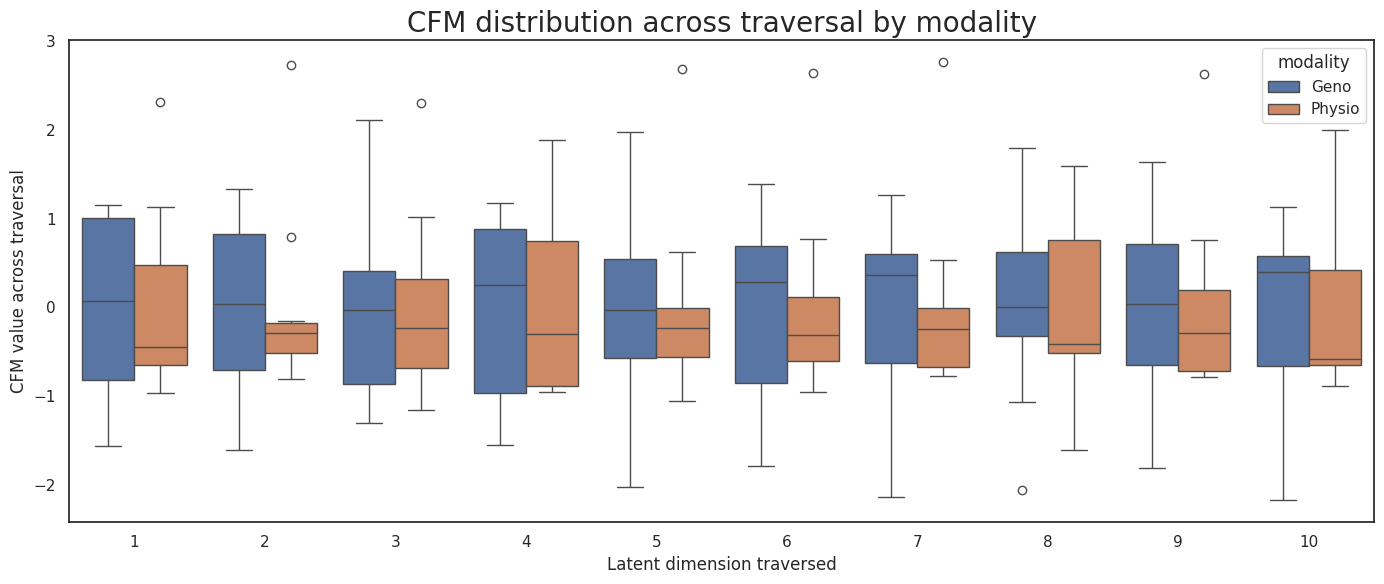

In [31]:
plt.figure(figsize=(14, 6))
sns.boxplot(
    data=cfm_df,
    x="latent_dim",
    y="cfm_value",
    hue="modality",
)
plt.xlabel("Latent dimension traversed")
plt.ylabel("CFM value across traversal")
plt.title("CFM distribution across traversal by modality", fontsize=20)
plt.tight_layout()
plt.show()

In [32]:
cfm_summary_table = (
    cfm_summary_df
    .pivot(index="latent_dim", columns="modality", values="cfm_variance")
    .reset_index()
)

cfm_summary_table

modality,latent_dim,Geno,Physio
0,1,0.996820,0.999723
1,2,0.998058,0.999840
2,3,0.997606,0.998380
3,4,0.998151,0.998048
4,5,0.997733,0.998306
5,6,0.998192,0.997770
6,7,0.997752,0.997845
7,8,0.997186,0.989520
8,9,0.997756,0.997944
9,10,0.997724,0.997884


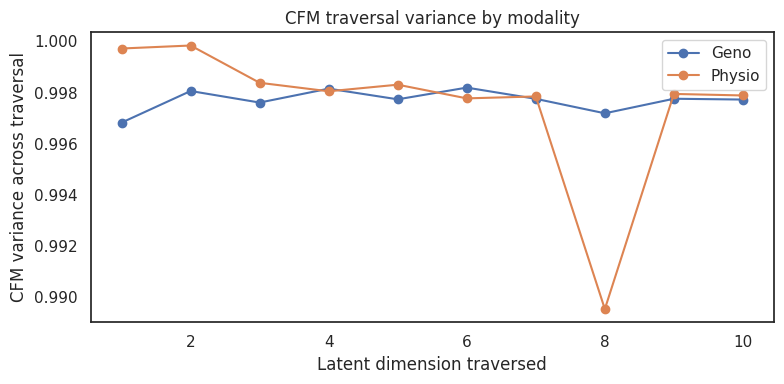

In [33]:
plt.figure(figsize=(8, 4))
plt.plot(
    cfm_summary_table["latent_dim"],
    cfm_summary_table["Geno"],
    marker="o",
    label="Geno",
)
plt.plot(
    cfm_summary_table["latent_dim"],
    cfm_summary_table["Physio"],
    marker="o",
    label="Physio",
)
plt.xlabel("Latent dimension traversed")
plt.ylabel("CFM variance across traversal")
plt.title("CFM traversal variance by modality")
plt.legend()
plt.tight_layout()
plt.show()

KL divergence across encoders

First: Looking at decoder gradients to determine which LV are the most important to reconstruction

In [59]:
# to do this, we calculate the gradient of the latent vector z with respect to the decoder output 
# (this is a similar concept to the latent traversal analysis that is done previously)
def compute_integrated_gradients(decoder, z, baseline_type="mean", steps=50):
    # z is the latent tensor
    # z baseline is the reference latent tensor
    # steps is the number of interpolation steps
    decoder.eval()
    num_samples, latent_dim = z.shape
    # z = torch.Tensor(z)

    if baseline_type=="mean":
        z_baseline = z.mean(dim=0, keepdim=True)
    elif baseline_type=="zero": 
        z_baseline = torch.zeros_like(z)
    else: 
        raise ValueError(f"Unknown baseline_type: {baseline_type}")

    # create interpolated sammples along line between z_baseline and z
    alphas = torch.linspace(0.0, 1.0, steps, device=z.device).view(steps, 1, 1)

    # compute steps in parallel
    relative_diff = z - z_baseline
    interpolated_z = z_baseline + alphas * relative_diff # may have to reshape z_baseline and relative_diff (unsqueeze)

    print(interpolated_z.shape)
    # reshaping to steps * batch_size, latent_dim
    interpolated_z = interpolated_z.reshape(-1, latent_dim).detach().requires_grad_(True)

    with torch.enable_grad(): 
        recon = decoder(interpolated_z)

        # compute gradients for all interpolated points
        grad_outputs = torch.ones_like(recon)
        grads = torch.autograd.grad(outputs=recon, inputs=interpolated_z, grad_outputs=grad_outputs, create_graph=False)[0]

    # reshape back to (steps, batch_size, latent_dim)
    grads = grads.view(steps, z.size(0), z.size(-1))

    # approximate integral via Reimann sum
    avg_grads = torch.mean(grads, dim=0)

    ig_attr = relative_diff * avg_grads

    # global importance is equal to average absolute attribution
    importance_dim = ig_attr.abs().mean(dim=0)

    ranked_inds = torch.argsort(importance_dim, descending=True)

    return ranked_inds, importance_dim

In [39]:
geno_decoder = vae.vaes[0].decoder
physio_decoder = vae.vaes[1].decoder

In [60]:
geno_ranked_inds, geno_lv_importance = compute_integrated_gradients(geno_decoder, torch.Tensor(latent_space_geno.iloc[:, :latent_dim].values), baseline_type="mean", steps=50)

torch.Size([50, 501, 10])


RuntimeError: mat1 and mat2 shapes cannot be multiplied (25050x10 and 11x12)

In [49]:
latent_space_geno.iloc[:, :latent_dim].shape

(501, 10)